In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(8)

city = "Poltava"

months = ["Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
          "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"]

temperature = np.array([
    -5, -4, 1, 10, 16, 19,
    21, 20, 14, 8, 1, -3
])

heating_days = np.clip(
    18 - temperature + np.random.normal(0, 1.5, 12),
    0,
    30
).round().astype(int)

cost = (
    0.15 * heating_days
    + np.random.normal(0, 1.0, 12)
)

cost = np.maximum(cost, 0).round(1)

print("Місто:", city)
print()
print("Місяць | Температура | Опалювальні дні | Витрати")

for i in range(12):
    print(
        f"{months[i]:5} | "
        f"{temperature[i]:11} | "
        f"{heating_days[i]:16} | "
        f"{cost[i]:7.1f}"
    )

Місто: Poltava

Місяць | Температура | Опалювальні дні | Витрати
Січ   |          -5 |               23 |     2.3
Лют   |          -4 |               24 |     2.9
Бер   |           1 |               14 |     1.7
Кві   |          10 |                6 |     0.1
Тра   |          16 |                0 |     0.9
Чер   |          19 |                3 |     0.2
Лип   |          21 |                0 |     0.0
Сер   |          20 |                1 |     0.0
Вер   |          14 |                5 |     2.1
Жов   |           8 |               11 |     1.0
Лис   |           1 |               15 |     2.1
Гру   |          -3 |               24 |     4.0


In [7]:
x = temperature
y = cost

# Лінійна регресія y = b0 + b1*x
b1, b0 = np.polyfit(x, y, 1)

predicted = b0 + b1 * x
residuals = y - predicted

print(f"b1 = {b1:.3f}")
print(f"b0 = {b0:.3f}")
print(f"Рівняння: витрати = {b0:.3f} + ({b1:.3f}) × температура")

b1 = -0.108
b0 = 2.327
Рівняння: витрати = 2.327 + (-0.108) × температура


In [8]:
r = np.corrcoef(x, y)[0, 1]

ss_res = np.sum((y - predicted) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r2_1 = r ** 2
r2_2 = 1 - ss_res / ss_tot

print(f"r = {r:.3f}")
print(f"R² через r² = {r2_1:.3f}")
print(f"R² через SS = {r2_2:.3f}")

r = -0.828
R² через r² = 0.686
R² через SS = 0.686


In [9]:
print("Місяць | X | Фактичне Y | Прогноз | Залишок")

for i in range(12):
    print(
        f"{months[i]:5} | "
        f"{x[i]:2} | "
        f"{y[i]:10.1f} | "
        f"{predicted[i]:7.3f} | "
        f"{residuals[i]:7.3f}"
    )

Місяць | X | Фактичне Y | Прогноз | Залишок
Січ   | -5 |        2.3 |   2.869 |  -0.569
Лют   | -4 |        2.9 |   2.761 |   0.139
Бер   |  1 |        1.7 |   2.219 |  -0.519
Кві   | 10 |        0.1 |   1.243 |  -1.143
Тра   | 16 |        0.9 |   0.592 |   0.308
Чер   | 19 |        0.2 |   0.267 |  -0.067
Лип   | 21 |        0.0 |   0.050 |  -0.050
Сер   | 20 |        0.0 |   0.159 |  -0.159
Вер   | 14 |        2.1 |   0.809 |   1.291
Жов   |  8 |        1.0 |   1.460 |  -0.460
Лис   |  1 |        2.1 |   2.219 |  -0.119
Гру   | -3 |        4.0 |   2.652 |   1.348


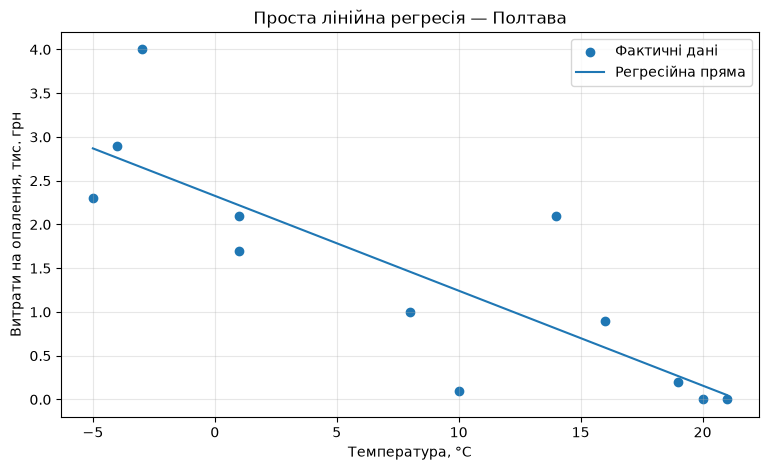

In [10]:
order = np.argsort(x)

plt.figure(figsize=(9, 5))

plt.scatter(x, y, label="Фактичні дані")
plt.plot(
    x[order],
    predicted[order],
    label="Регресійна пряма"
)

plt.xlabel("Температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title("Проста лінійна регресія — Полтава")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

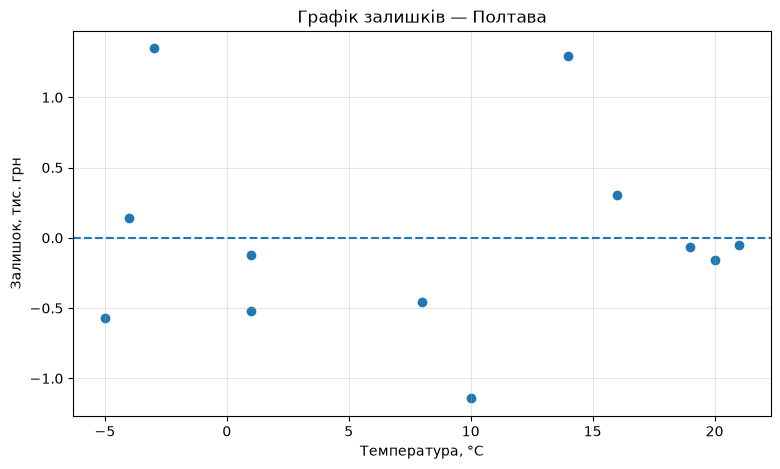

In [11]:
plt.figure(figsize=(9, 5))

plt.scatter(x, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Температура, °C")
plt.ylabel("Залишок, тис. грн")
plt.title("Графік залишків — Полтава")
plt.grid(True, alpha=0.3)

plt.show()

In [12]:
new_temperature = -10

forecast = b0 + b1 * new_temperature

print(f"Прогноз для {new_temperature}°C: {forecast:.3f} тис. грн")
print(f"Діапазон температур: від {x.min()}°C до {x.max()}°C")

if x.min() <= new_temperature <= x.max():
    print("Це прогноз у межах спостереженого діапазону.")
else:
    print("Це екстраполяція за межі спостереженого діапазону.")

Прогноз для -10°C: 3.411 тис. грн
Діапазон температур: від -5°C до 21°C
Це екстраполяція за межі спостереженого діапазону.


In [13]:
n = len(x)

t_stat = r * math.sqrt(
    (n - 2) / (1 - r**2)
)

print(f"t = {t_stat:.3f}")
print("p-value ≈ 0.012")

t = -4.675
p-value ≈ 0.012
